In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install statsmodels matplotlib scipy pandas numpy -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

S1_DIR   = "/content/drive/MyDrive/sprint1 v9 results"
CKPT_DIR = "/content/drive/MyDrive/sprint1 v9 results/sprint1"
DATA_DIR = "/content/drive/MyDrive/workspace_backup/thesis"

print("✓" if os.path.exists(f"{S1_DIR}/sprint1_Main.py") else "✗", "sprint1_Main.py")

for ext in (".parquet", ".csv"):
    if os.path.exists(f"{DATA_DIR}/test{ext}"):
        print(f"✓ test{ext}"); break
else:
    print("✗ test data missing")

for hz in ("10min", "30min", "60min", "120min"):
    for name in ("pred_hetero_ensemble.npy", "pred_homo_ensemble.npy"):
        if os.path.exists(f"{CKPT_DIR}/{hz}/{name}"):
            print(f"✓ {hz}/{name}"); break
    else:
        print(f"✗ {hz}: no ensemble .npy")

✓ sprint1_Main.py
✓ test.parquet
✓ 10min/pred_hetero_ensemble.npy
✓ 30min/pred_hetero_ensemble.npy
✓ 60min/pred_hetero_ensemble.npy
✓ 120min/pred_hetero_ensemble.npy


In [ ]:
!python "/content/drive/MyDrive/sprint1 v9 results/residual_diagnostics_figure.py" \
    --sprint1-dir "/content/drive/MyDrive/sprint1 v9 results" \
    --data-dir    "/content/drive/MyDrive/workspace_backup/thesis" \
    --ckpt-dir    "/content/drive/MyDrive/sprint1 v9 results/sprint1" \
    --output-dir  "/content/drive/MyDrive/workspace/thesis_figures"

PyTorch 2.10.0+cpu -- cpu
No CUDA -- XGBoost on CPU
Loaded sprint1_Main.py from /content/drive/MyDrive/sprint1 v9 results
Loading test data from /content/drive/MyDrive/workspace_backup/thesis/test.parquet ...
  1,680,285 rows loaded

Processing 10min (shift=2) ...
  10min: loaded hetero_ensemble, n=1,670,443, mean_resid=0.004290, std=3.0464

Processing 30min (shift=6) ...
  30min: loaded hetero_ensemble, n=1,650,759, mean_resid=0.008280, std=4.3373

Processing 60min (shift=12) ...
  60min: loaded hetero_ensemble, n=1,621,233, mean_resid=-0.010721, std=4.8381

Processing 120min (shift=24) ...
  120min: loaded hetero_ensemble, n=1,562,181, mean_resid=-0.084855, std=5.2486

Saved: /content/drive/MyDrive/workspace/thesis_figures/residual_diagnostics_figure.pdf
Done.


Selecting previously unselected package poppler-utils.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...


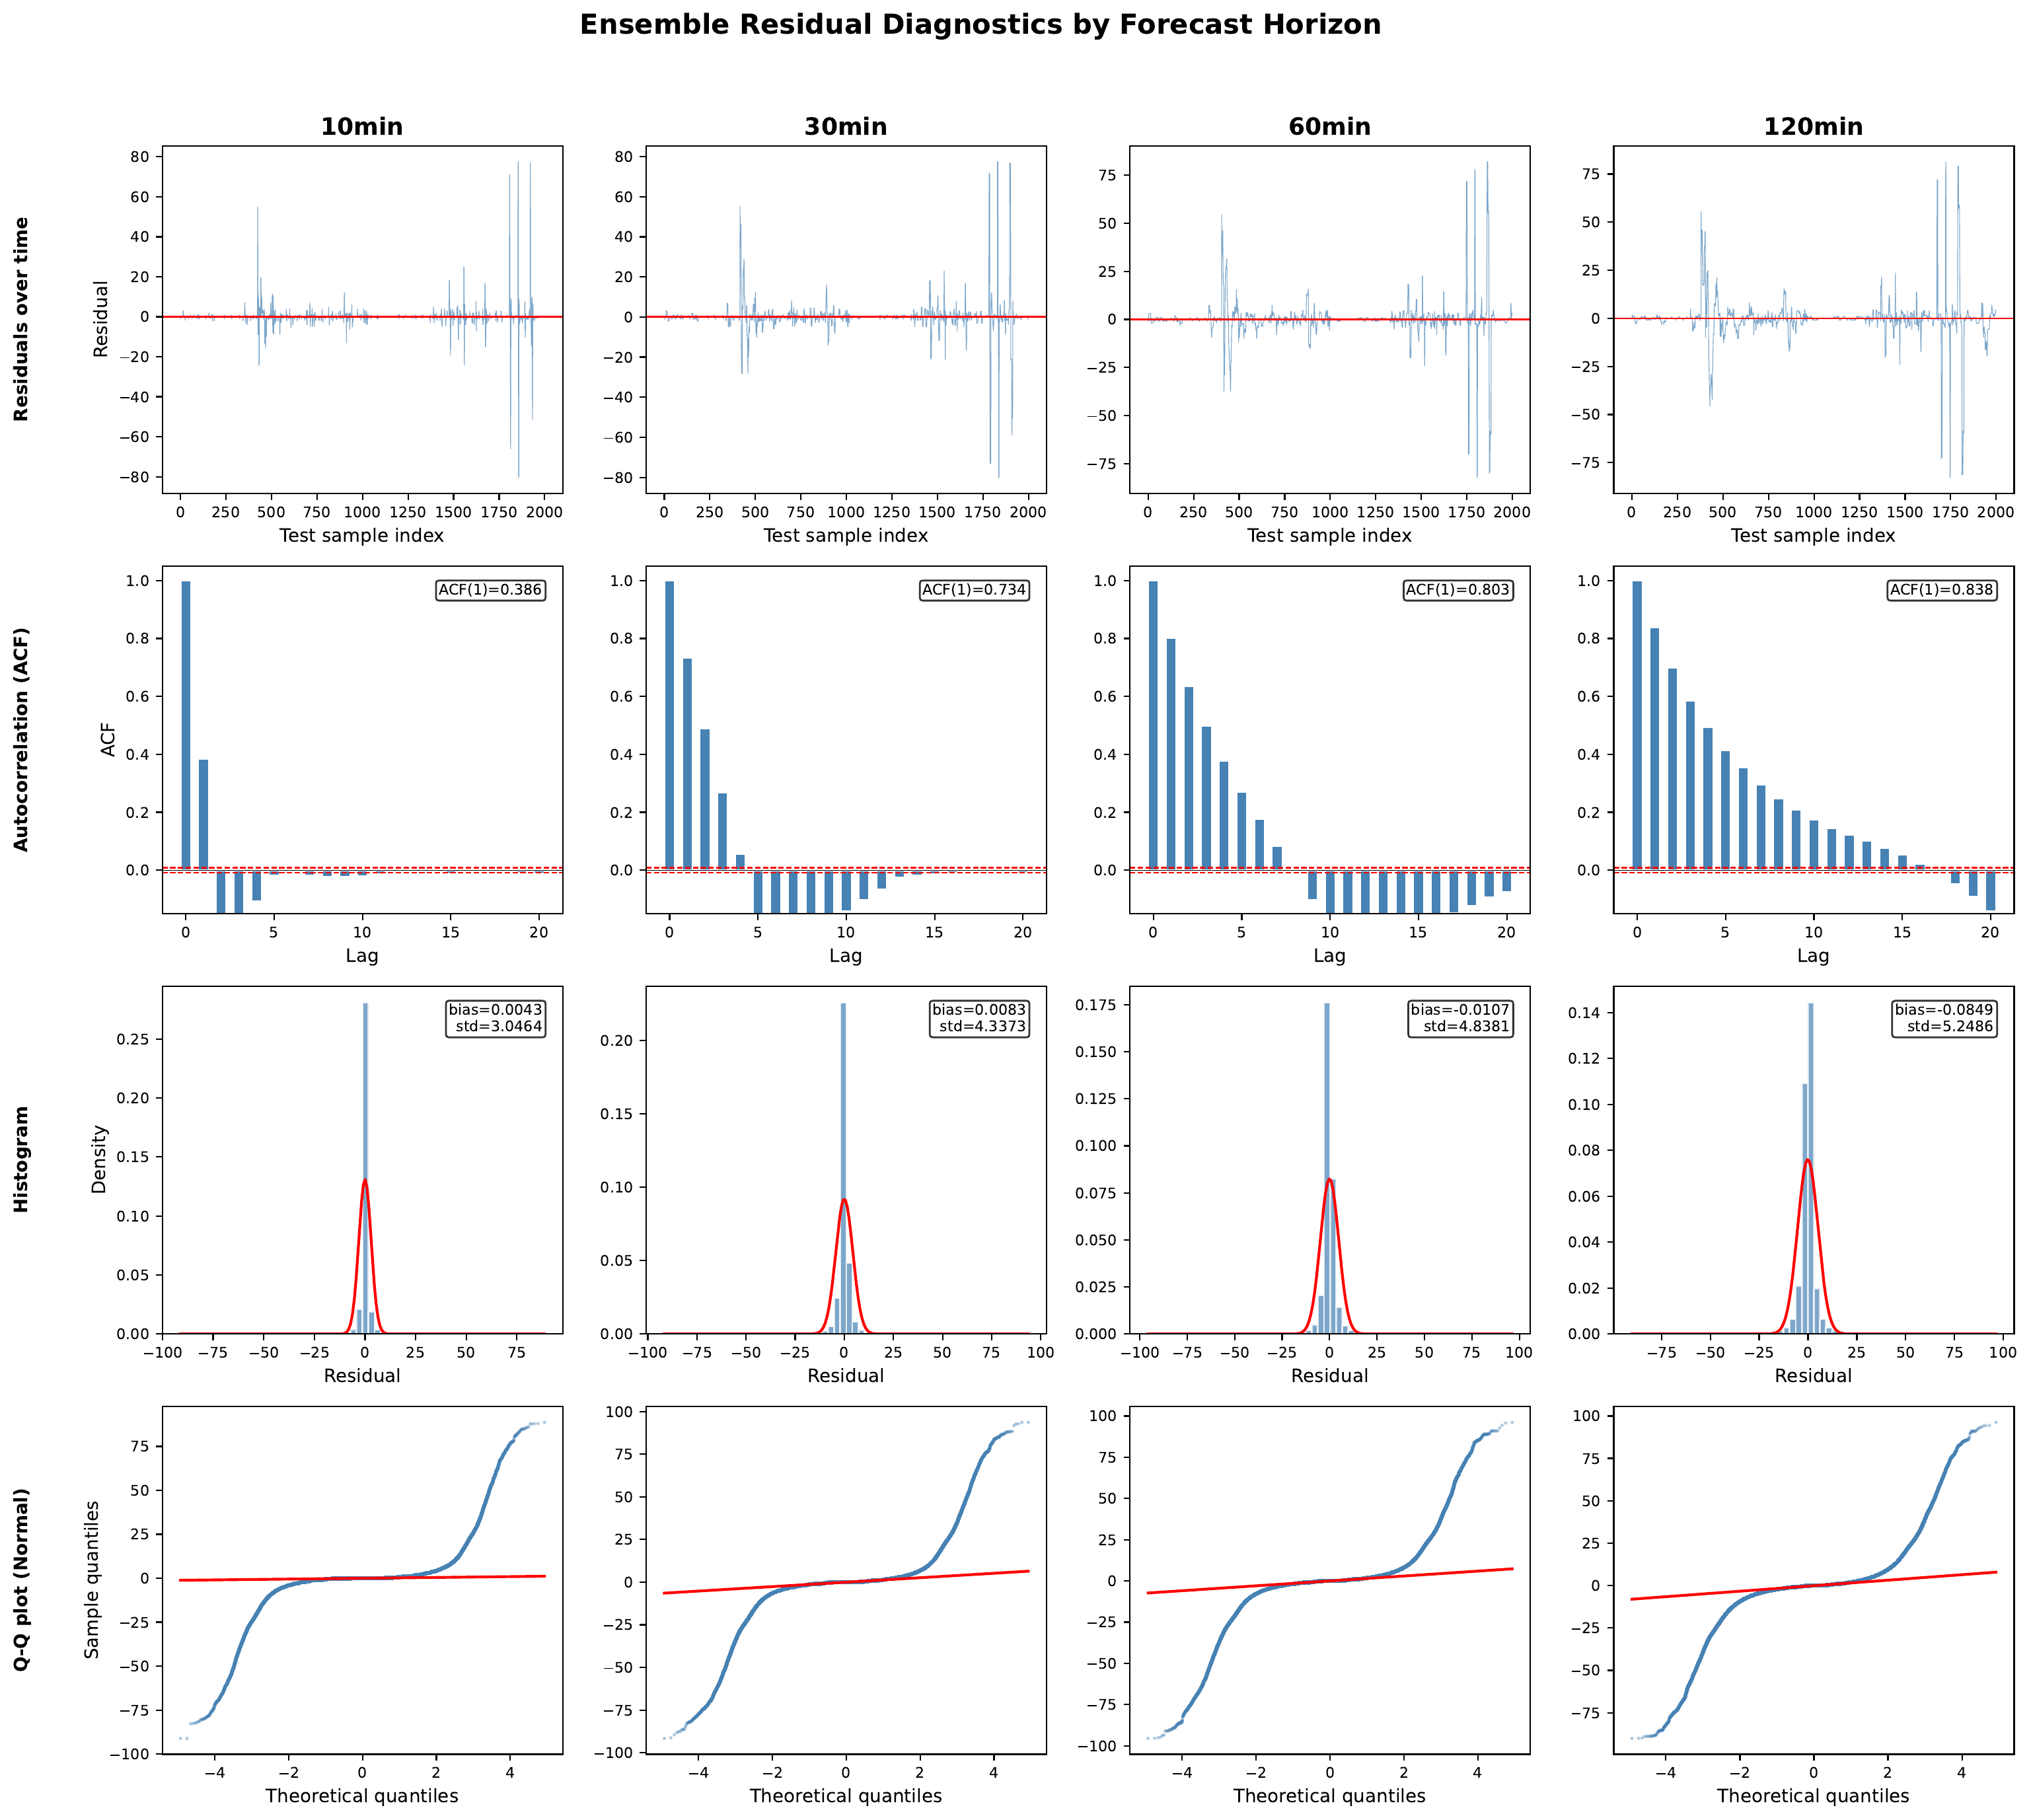

In [8]:
!pip install pdf2image -q
!apt-get install -y poppler-utils -qq

from IPython.display import display, Image
from pdf2image import convert_from_path

pdf_path = "/content/drive/MyDrive/workspace/thesis_figures/residual_diagnostics_figure.pdf"
pages = convert_from_path(pdf_path, dpi=200)
pages[0].save("/tmp/preview.png")
display(Image(filename="/tmp/preview.png"))